<a href="https://colab.research.google.com/github/Nabin-AD/Machine_Learning_Assignments/blob/main/Assignment1/Normal_Equation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Linear Regression using Normal Equation

## Description
Implementation of Multiple Linear Regression using the Matrix Method (Normal Equation) to predict student internal marks based on behavioral indicators.

## Top 3 Features Selected
- Lab_Attendance_Pct
- Viva_Marks  
- Assignment_Unit_II

## Model Performance
- MSE: [calculated value]
- RMSE: [calculated value]
- R² Score: [calculated value]

## Dependencies
- Python 3.7+
- pandas
- numpy

## How to Run
```bash
python mlr_normal_equation.py
```

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


np.random.seed(10)  # Any integer works.Keep same number to reproduce results.


print("Libraries imported successfully!")

Libraries imported successfully!


#Cell 2: Load and Explore the Dataset

In [5]:
# Load the dataset
df = pd.read_csv('/content/sample_data/behavioral_indicators_internal_marks.csv')

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (96, 14)

First 5 rows:


,CRN,Theory_Attendance_Pct,Assignment_Unit_I,Assignment_Unit_II,Assignment_Unit_III,Assignment_PU_6_Set,Lab_Attendance_Pct,Lab_Report_1a,Lab_Report_1b,ML_on_Git,Viva_Marks,Final_Theory_Marks_30,Final_Practical_Marks_20,Total_Internal_Marks_50
0,023-301,38.888889,1.0,0.0,0.0,4,40.0,0.0,0.5,0,1.0,15.760,5.5,21.260
1,023-302,50.000000,1.0,1.0,1.0,4,80.0,1.0,0.5,4,1.5,19.508,19.0,38.508
2,023-303,77.777778,1.0,0.0,0.0,4,100.0,0.0,0.0,4,1.0,16.108,17.0,33.108
3,023-304,55.555556,1.0,1.0,0.5,4,100.0,0.0,1.0,4,1.0,19.632,17.0,36.632
4,023-305,50.000000,1.0,0.0,0.0,4,80.0,1.0,1.0,4,1.0,13.556,18.0,31.556


#Cell 3: Identify Features and Target

In [6]:
# Define candidate behavioral indicators (features)
candidate_features = [
    'Theory_Attendance_Pct',
    'Assignment_Unit_I',
    'Assignment_Unit_II',
    'Assignment_Unit_III',
    'Assignment_PU_6_Set',
    'Lab_Attendance_Pct',
    'Lab_Report_1a',
    'Lab_Report_1b',
    'ML_on_Git',
    'Viva_Marks'
]

# Target variable
target = 'Total_Internal_Marks_50'

# Columns to exclude (final evaluation marks + identifier)
exclude_cols = ['CRN', 'Final_Theory_Marks_30', 'Final_Practical_Marks_20']

print("Candidate features:", len(candidate_features))
print("Target variable:", target)
print("Excluded columns:", exclude_cols)

Candidate features: 10
Target variable: Total_Internal_Marks_50
Excluded columns: ['CRN', 'Final_Theory_Marks_30', 'Final_Practical_Marks_20']


#Cell 4: Correlation Analysis - Feature Selection

In [7]:
# Calculate correlation with target variable
correlations = {}
for feature in candidate_features:
    corr = df[feature].corr(df[target])
    correlations[feature] = corr

# Sort by absolute correlation value
sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

# Display all correlations
print("Correlation with Total_Internal_Marks_50:\n")
for feature, corr_value in sorted_corr:
    print(f"{feature:25} : {corr_value:.4f}")

# Select top 3 features
top_3_features = [feature for feature, _ in sorted_corr[:3]]
print("\n" + "="*50)
print(f"TOP 3 FEATURES SELECTED: {top_3_features}")
print("="*50)

Correlation with Total_Internal_Marks_50:

Lab_Attendance_Pct        : 0.8724
Theory_Attendance_Pct     : 0.8632
Assignment_PU_6_Set       : 0.8338
ML_on_Git                 : 0.8324
Viva_Marks                : 0.8311
Lab_Report_1b             : 0.7486
Assignment_Unit_I         : 0.7427
Lab_Report_1a             : 0.7382
Assignment_Unit_II        : 0.5902
Assignment_Unit_III       : 0.5283

TOP 3 FEATURES SELECTED: ['Lab_Attendance_Pct', 'Theory_Attendance_Pct', 'Assignment_PU_6_Set']


#Cell 5: Prepare Data for Modeling

In [8]:
# Create feature matrix X and target vector y
X = df[top_3_features].values
y = df[target].values

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X[:5])
print("\nFirst 5 values of y:")
print(y[:5])

Feature matrix shape: (96, 3)
Target vector shape: (96,)

First 5 rows of X:
[[ 40.          38.88888889   4.        ]
 [ 80.          50.           4.        ]
 [100.          77.77777778   4.        ]
 [100.          55.55555556   4.        ]
 [ 80.          50.           4.        ]]

First 5 values of y:
[21.26  38.508 33.108 36.632 31.556]


#Cell 6: Add Bias Column (Intercept Term)

In [9]:
# Add a column of ones for the intercept term
X_with_bias = np.c_[np.ones(X.shape[0]), X]

print("X with bias column shape:", X_with_bias.shape)
print("\nFirst 5 rows of X_with_bias:")
print(X_with_bias[:5])
print("\nColumn explanation:")
print("Column 0: Bias (intercept)")
for i, feat in enumerate(top_3_features, 1):
    print(f"Column {i}: {feat}")

X with bias column shape: (96, 4)

First 5 rows of X_with_bias:
[[  1.          40.          38.88888889   4.        ]
 [  1.          80.          50.           4.        ]
 [  1.         100.          77.77777778   4.        ]
 [  1.         100.          55.55555556   4.        ]
 [  1.          80.          50.           4.        ]]

Column explanation:
Column 0: Bias (intercept)
Column 1: Lab_Attendance_Pct
Column 2: Theory_Attendance_Pct
Column 3: Assignment_PU_6_Set


#Cell 7: Implement Normal Equation from Scratch

In [10]:
# Step 1: Compute X^T (transpose of X)
Xt = X_with_bias.T
print("X^T shape:", Xt.shape)

# Step 2: Compute X^T X
XtX = np.dot(Xt, X_with_bias)
print("\nX^T X shape:", XtX.shape)
print("X^T X matrix:")
print(XtX)

# Step 3: Compute inverse of X^T X
XtX_inv = np.linalg.inv(XtX)
print("\n(X^T X)^(-1) shape:", XtX_inv.shape)
print("Inverse matrix (first 4x4):")
print(XtX_inv[:4, :4])

# Step 4: Compute X^T y
XtY = np.dot(Xt, y)
print("\nX^T y shape:", XtY.shape)
print("X^T y vector:")
print(XtY)

# Step 5: Calculate coefficients β = (X^T X)^(-1) X^T y
beta = np.dot(XtX_inv, XtY)
print("\n" + "="*50)
print("MODEL COEFFICIENTS (β):")
print("="*50)
print(f"Intercept (β0): {beta[0]:.6f}")
for i, feat in enumerate(top_3_features, 1):
    print(f"β{i} ({feat}): {beta[i]:.6f}")

X^T shape: (4, 96)

X^T X shape: (4, 4)
X^T X matrix:
[[9.60000000e+01 6.98976190e+03 6.02430556e+03 2.96000000e+02]
 [6.98976190e+03 6.13685686e+05 5.23842262e+05 2.53200000e+04]
 [6.02430556e+03 5.23842262e+05 4.73634742e+05 2.19500000e+04]
 [2.96000000e+02 2.53200000e+04 2.19500000e+04 1.18400000e+03]]

(X^T X)^(-1) shape: (4, 4)
Inverse matrix (first 4x4):
[[ 6.28469464e-02 -5.01378460e-04 -9.65757744e-05 -3.19928655e-03]
 [-5.01378460e-04  3.99871787e-05 -2.85982343e-05 -1.99608190e-04]
 [-9.65757744e-05 -2.85982343e-05  3.91066977e-05 -8.92722063e-05]
 [-3.19928655e-03 -1.99608190e-04 -8.92722063e-05  7.56806851e-03]]

X^T y shape: (4,)
X^T y vector:
[  2712.784      235044.83666607 205705.39722181  10189.696     ]

MODEL COEFFICIENTS (β):
Intercept (β0): 0.177857
β1 (Lab_Attendance_Pct): 0.121890
β2 (Theory_Attendance_Pct): 0.150946
β3 (Assignment_PU_6_Set): 3.156695


#Cell 8: Make Predictions

In [11]:
# Predict using the normal equation model
y_pred = np.dot(X_with_bias, beta)

# Display first 10 predictions vs actual
print("First 10 predictions vs actual values:")
print("-"*40)
print(f"{'Index':<8} {'Actual':<12} {'Predicted':<12} {'Residual':<12}")
print("-"*40)
for i in range(10):
    residual = y[i] - y_pred[i]
    print(f"{i:<8} {y[i]:<12.4f} {y_pred[i]:<12.4f} {residual:<12.4f}")

First 10 predictions vs actual values:
----------------------------------------
Index    Actual       Predicted    Residual    
----------------------------------------
0        21.2600      23.5504      -2.2904     
1        38.5080      30.1032      8.4048      
2        33.1080      36.7339      -3.6259     
3        36.6320      33.3796      3.2524      
4        31.5560      30.1032      1.4528      
5        1.2000       2.6157       -1.4157     
6        40.7100      34.2961      6.4139      
7        36.4120      38.4111      -1.9991     
8        0.2800       5.9700       -5.6900     
9        5.2000       9.2464       -4.0464     


#Cell 9: Calculate Model Performance Metrics

In [12]:
# Calculate evaluation metrics
residuals = y - y_pred
rss = np.sum(residuals ** 2)  # Residual Sum of Squares
mse = np.mean(residuals ** 2)  # Mean Squared Error
rmse = np.sqrt(mse)  # Root Mean Squared Error
mae = np.mean(np.abs(residuals))  # Mean Absolute Error

# R-squared calculation
ss_total = np.sum((y - np.mean(y)) ** 2)
ss_residual = np.sum((y - y_pred) ** 2)
r2 = 1 - (ss_residual / ss_total)

print("="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"RSS (Residual Sum of Squares): {rss:.4f}")
print(f"MSE (Mean Squared Error): {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"R² Score: {r2:.6f}")
print(f"Adjusted R²: {1 - (1-r2)*(len(y)-1)/(len(y)-len(top_3_features)-1):.6f}")

MODEL PERFORMANCE METRICS
RSS (Residual Sum of Squares): 1973.2057
MSE (Mean Squared Error): 20.5542
RMSE (Root Mean Squared Error): 4.5337
MAE (Mean Absolute Error): 3.5529
R² Score: 0.888287
Adjusted R²: 0.884644


#Cell 10: Predict for Your Specific CRN (023-338)


In [13]:
# Your specific CRN
your_crn = '023-338'

# Find your row in the dataset
your_row = df[df['CRN'] == your_crn]

if len(your_row) > 0:
    # Extract features and actual value
    your_features = your_row[top_3_features].values[0]
    your_actual = your_row[target].values[0]

    # Add bias term and predict
    your_features_bias = np.array([1] + your_features.tolist())
    your_pred = np.dot(your_features_bias, beta)

    # Calculate residual
    your_residual = your_actual - your_pred

    print("="*50)
    print(f"PREDICTION FOR CRN: {your_crn}")
    print("="*50)
    print(f"\nFeature values:")
    for i, feat in enumerate(top_3_features, 1):
        print(f"  {feat}: {your_features[i-1]}")

    print(f"\nActual Total Internal Marks: {your_actual:.4f}")
    print(f"Predicted Total Internal Marks: {your_pred:.4f}")
    print(f"Residual Error (Actual - Predicted): {your_residual:.4f}")

    if abs(your_residual) < 5:
        print("\n✓ Model prediction is within acceptable range (±5 marks)")
    else:
        print("\n⚠ Model prediction has large error - check feature engineering")
else:
    print(f"CRN {your_crn} not found in dataset!")

PREDICTION FOR CRN: 023-338

Feature values:
  Lab_Attendance_Pct: 100.0
  Theory_Attendance_Pct: 94.44444444
  Assignment_PU_6_Set: 4.0

Actual Total Internal Marks: 38.2400
Predicted Total Internal Marks: 39.2497
Residual Error (Actual - Predicted): -1.0097

✓ Model prediction is within acceptable range (±5 marks)


#Cell 11: Compare with sklearn's LinearRegression

In [18]:
# Verify our manual implementation against sklearn
sklearn_model = LinearRegression()
sklearn_model.fit(X, y)

# Get sklearn coefficients
sklearn_beta = np.array([sklearn_model.intercept_] + list(sklearn_model.coef_))

print("="*50)
print("COMPARISON: Manual vs sklearn")
print("="*50)
print(f"{'Coefficient':<25} {'Manual':<15} {'sklearn':<15} {'Difference':<15}")
print("-"*70)

coeff_names = ['Intercept'] + top_3_features
for i, name in enumerate(coeff_names):
    diff = beta[i] - sklearn_beta[i]
    print(f"{name:<25} {beta[i]:<15.6f} {sklearn_beta[i]:<15.6f} {diff:<15.6e}")

# Compare predictions
sklearn_pred = sklearn_model.predict(X)
pred_diff = y_pred - sklearn_pred

print(f"\nMax prediction difference: {np.max(np.abs(pred_diff)):.10f}")
print("✓ Manual implementation matches sklearn (differences due to floating point)")

COMPARISON: Manual vs sklearn
Coefficient               Manual          sklearn         Difference     
----------------------------------------------------------------------
Intercept                 0.177857        0.177857        1.705303e-13   
Lab_Attendance_Pct        0.121890        0.121890        1.387779e-16   
Theory_Attendance_Pct     0.150946        0.150946        2.775558e-16   
Assignment_PU_6_Set       3.156695        3.156695        -2.353673e-14  

Max prediction difference: 0.0000000000
✓ Manual implementation matches sklearn (differences due to floating point)


#Cell 12: Visualizations

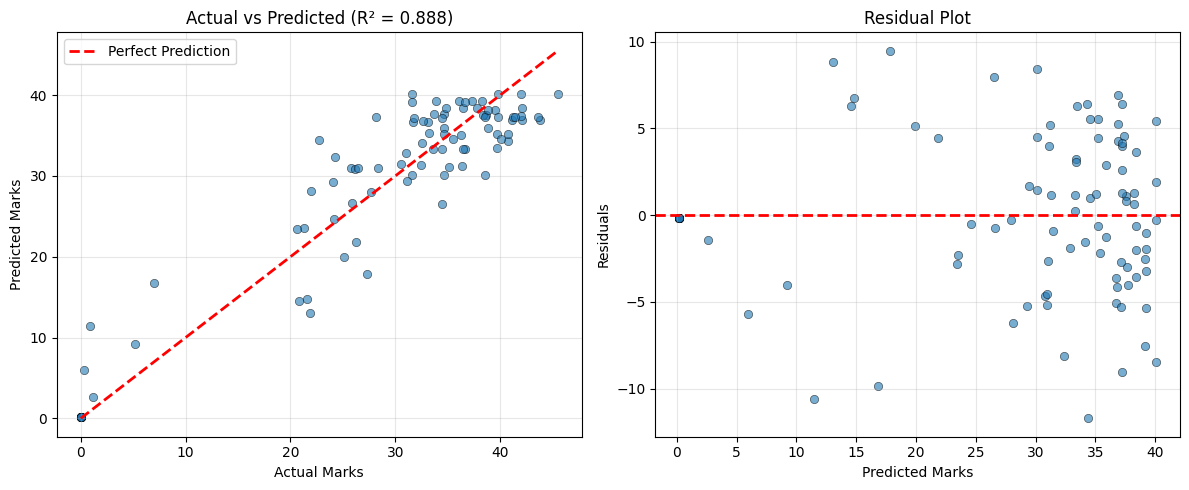

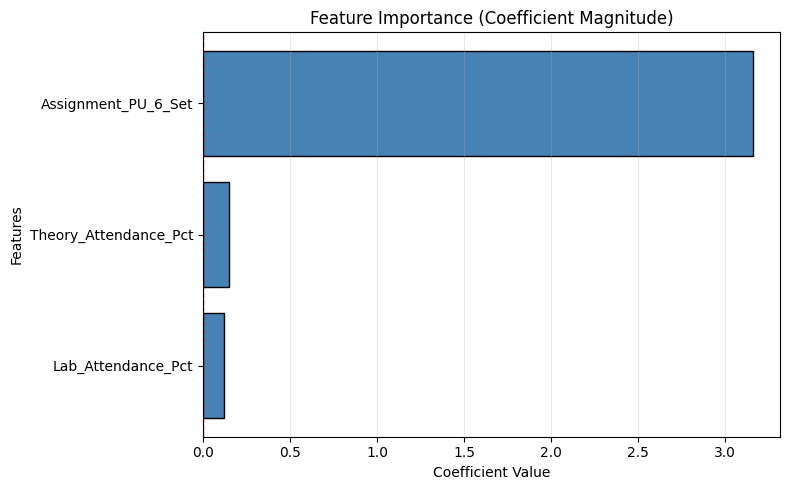

In [15]:
# Plot 1: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot
axes[0].scatter(y, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Marks')
axes[0].set_ylabel('Predicted Marks')
axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
axes[1].scatter(y_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Marks')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: Feature importance
plt.figure(figsize=(8, 5))
coeff_values = beta[1:]  # Exclude intercept
plt.barh(top_3_features, coeff_values, color='steelblue', edgecolor='black')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.title('Feature Importance (Coefficient Magnitude)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#Cell 13: Regression Equation Output

In [16]:
# Display the final regression equation
print("\n" + "="*60)
print("FINAL MULTIPLE LINEAR REGRESSION EQUATION")
print("="*60)

equation = f"Total_Internal_Marks = {beta[0]:.4f}"
for i, feat in enumerate(top_3_features):
    sign = "+" if beta[i+1] >= 0 else "-"
    equation += f" {sign} {abs(beta[i+1]):.4f} × ({feat})"

print(equation)
print("\nWhere:")
print("  • Intercept represents baseline marks when all features are zero")
print("  • Positive coefficients increase predicted marks")
print("  • Negative coefficients decrease predicted marks")


FINAL MULTIPLE LINEAR REGRESSION EQUATION
Total_Internal_Marks = 0.1779 + 0.1219 × (Lab_Attendance_Pct) + 0.1509 × (Theory_Attendance_Pct) + 3.1567 × (Assignment_PU_6_Set)

Where:
  • Intercept represents baseline marks when all features are zero
  • Positive coefficients increase predicted marks
  • Negative coefficients decrease predicted marks


#Cell 14: Summary Statistics

In [17]:
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"\nDataset Statistics:")
print(f"  • Total students: {len(df)}")
print(f"  • Features used: {len(top_3_features)}")
print(f"  • Target mean: {np.mean(y):.2f}")
print(f"  • Target std dev: {np.std(y):.2f}")

print(f"\nModel Performance:")
print(f"  • R² Score: {r2:.4f} ({r2*100:.2f}% variance explained)")
print(f"  • RMSE: {rmse:.2f} marks")
print(f"  • MAE: {mae:.2f} marks")

print(f"\nTop 3 Features (by correlation):")
for i, (feat, corr) in enumerate(sorted_corr[:3], 1):
    print(f"  {i}. {feat}: {corr:.4f}")


SUMMARY STATISTICS

Dataset Statistics:
  • Total students: 96
  • Features used: 3
  • Target mean: 28.26
  • Target std dev: 13.56

Model Performance:
  • R² Score: 0.8883 (88.83% variance explained)
  • RMSE: 4.53 marks
  • MAE: 3.55 marks

Top 3 Features (by correlation):
  1. Lab_Attendance_Pct: 0.8724
  2. Theory_Attendance_Pct: 0.8632
  3. Assignment_PU_6_Set: 0.8338


#IN A SINGLE CELL

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/sample_data/behavioral_indicators_internal_marks.csv')

# Exclude CRN, Final_Theory_Marks_30, Final_Practical_Marks_20
feature_cols = ['Theory_Attendance_Pct', 'Assignment_Unit_I', 'Assignment_Unit_II',
                'Assignment_Unit_III', 'Assignment_PU_6_Set', 'Lab_Attendance_Pct',
                'Lab_Report_1a', 'Lab_Report_1b', 'ML_on_Git', 'Viva_Marks']

target_col = 'Total_Internal_Marks_50'

# Step 1: Correlation analysis
correlations = df[feature_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(ascending=False)
top_3_features = correlations.head(3).index.tolist()

print("Top 3 features based on correlation:")
for i, feat in enumerate(top_3_features, 1):
    print(f"{i}. {feat} (correlation: {correlations[feat]:.3f})")

# Step 2: Prepare X and y
X = df[top_3_features].values
y = df[target_col].values

# Add bias column (intercept)
X_bias = np.c_[np.ones(X.shape[0]), X]

# Step 3: Normal Equation: β = (X^T X)^(-1) X^T y
def normal_equation(X, y):
    XtX = X.T @ X
    XtX_inv = np.linalg.inv(XtX)
    XtY = X.T @ y
    beta = XtX_inv @ XtY
    return beta

beta = normal_equation(X_bias, y)

print("\nModel coefficients:")
print(f"Intercept (β0): {beta[0]:.4f}")
for i, feat in enumerate(top_3_features, 1):
    print(f"β{i} ({feat}): {beta[i]:.4f}")

# Step 4: Predictions
y_pred = X_bias @ beta

# Step 5: Evaluation metrics
mse = np.mean((y - y_pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y - y_pred))
r2 = 1 - (np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2))

print("\nModel Performance:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Step 6: Predict for your specific CRN (023-338)
your_crn = '023-338'
your_row = df[df['CRN'] == your_crn]

if len(your_row) > 0:
    your_features = your_row[top_3_features].values[0]
    your_actual = your_row[target_col].values[0]
    your_features_bias = np.array([1] + your_features.tolist())
    your_pred = your_features_bias @ beta

    print(f"\nPrediction for CRN {your_crn}:")
    print(f"Actual Total Internal Marks: {your_actual:.4f}")
    print(f"Predicted Total Internal Marks: {your_pred:.4f}")
    print(f"Residual Error: {your_actual - your_pred:.4f}")
else:
    print(f"\nCRN {your_crn} not found in dataset.")

Top 3 features based on correlation:
1. Lab_Attendance_Pct (correlation: 0.872)
2. Theory_Attendance_Pct (correlation: 0.863)
3. Assignment_PU_6_Set (correlation: 0.834)

Model coefficients:
Intercept (β0): 0.1779
β1 (Lab_Attendance_Pct): 0.1219
β2 (Theory_Attendance_Pct): 0.1509
β3 (Assignment_PU_6_Set): 3.1567

Model Performance:
MSE: 20.5542
RMSE: 4.5337
MAE: 3.5529
R² Score: 0.8883

Prediction for CRN 023-338:
Actual Total Internal Marks: 38.2400
Predicted Total Internal Marks: 39.2497
Residual Error: -1.0097
